In this notebook, we investigate why CancerDetector yields the best uncalibrated results, but not the best calibrated results.

The main hypithesis is that the variance of the predictions of CancerDetector is higher than that of the other methods, which makes it more difficult to calibrate. 

In [1]:
import numpy as np
import pandas as pd
import scipy
import seaborn as sns

In [2]:
cancer_detector_uncal = np.load(
    "/staging/leuven/stg_00118/gbw-d-l0154/mnt/data/syto_experiments/mlflow/198121009408531961/aa2a6b70f9c94befa49b1b30ed2cecd6/artifacts/calibration/top_156_features/psls_calibrators_and_predictions/uncalibrated_predictions.npz"
)
cancer_detector_simplex = np.load(
    "/staging/leuven/stg_00118/gbw-d-l0154/mnt/data/syto_experiments/mlflow/198121009408531961/aa2a6b70f9c94befa49b1b30ed2cecd6/artifacts/calibration/top_156_features/psls_calibrators_and_predictions/linear_simplex_projection_predictions.npz"
)
cancer_detector = {
    "val_target": cancer_detector_uncal["val_target"],
    "uncal_val_pred": cancer_detector_uncal["val_pred"],
    "simplex_val_pred": cancer_detector_simplex["val_pred"],
    "test_target": cancer_detector_uncal["test_target"],
    "uncal_test_pred": cancer_detector_uncal["test_pred"],
    "simplex_test_pred": cancer_detector_simplex["test_pred"],
}

In [3]:
dismir_uncal = np.load(
    "/staging/leuven/stg_00118/gbw-d-l0154/mnt/data/syto_experiments/mlflow/198121009408531961/1e4280271d584868a0c816512ea995a4/artifacts/calibration/top_156_features/psls_calibrators_and_predictions/uncalibrated_predictions.npz"
)
dismir_simplex = np.load(
    "/staging/leuven/stg_00118/gbw-d-l0154/mnt/data/syto_experiments/mlflow/198121009408531961/1e4280271d584868a0c816512ea995a4/artifacts/calibration/top_156_features/psls_calibrators_and_predictions/linear_simplex_projection_predictions.npz"
)
dismir = {
    "val_target": dismir_uncal["val_target"],
    "uncal_val_pred": dismir_uncal["val_pred"],
    "simplex_val_pred": dismir_simplex["val_pred"],
    "test_target": dismir_uncal["test_target"],
    "uncal_test_pred": dismir_uncal["test_pred"],
    "simplex_test_pred": dismir_simplex["test_pred"],
}

In [4]:
cancer_detector_val_res = scipy.stats.linregress(
    cancer_detector["uncal_val_pred"], cancer_detector["val_target"]
)
cancer_detector_val_res.rvalue.mean()

np.float64(0.99489357414669)

In [5]:
dismir_val_res = scipy.stats.linregress(dismir["uncal_val_pred"], dismir["val_target"])
dismir_val_res.rvalue.mean()

np.float64(0.9495500764380762)

In [6]:
cancer_detector_test_res = scipy.stats.linregress(
    cancer_detector["uncal_test_pred"], cancer_detector["test_target"]
)
cancer_detector_test_res.rvalue.mean()

np.float64(0.9962907696061256)

In [7]:
dismir_test_res = scipy.stats.linregress(
    dismir["uncal_test_pred"], dismir["test_target"]
)
dismir_test_res.rvalue.mean()

np.float64(0.9504068168112071)

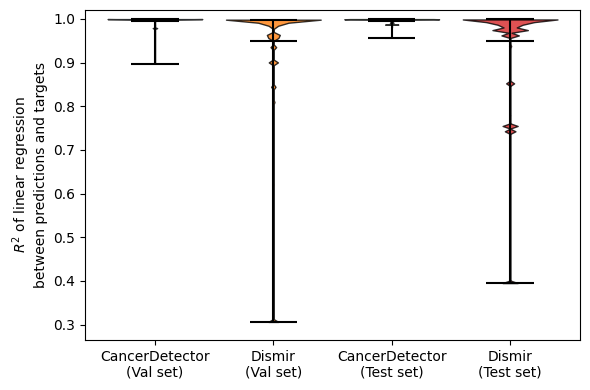

In [14]:
import matplotlib.pyplot as plt

data = [
    cancer_detector_val_res.rvalue,
    dismir_val_res.rvalue,
    cancer_detector_test_res.rvalue,
    dismir_test_res.rvalue,
]
labels = [
    "CancerDetector\n(Val set)",
    "Dismir\n(Val set)",
    "CancerDetector\n(Test set)",
    "Dismir\n(Test set)",
]

fig, ax = plt.subplots(figsize=(6, 4))
positions = np.arange(len(data))
violin_parts = ax.violinplot(
    data, positions=positions, showmeans=True, widths=0.8, bw_method=0.01
)

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
for body, color in zip(violin_parts["bodies"], colors):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.8)

if "cmeans" in violin_parts:
    violin_parts["cmeans"].set_color("black")
if "cbars" in violin_parts:
    violin_parts["cbars"].set_color("black")
if "cmins" in violin_parts:
    violin_parts["cmins"].set_color("black")
if "cmaxes" in violin_parts:
    violin_parts["cmaxes"].set_color("black")

# Add mean values below each mean bar
means = [np.mean(d) for d in data]
ymin = min(np.min(d) for d in data)
ymax = max(np.max(d) for d in data)
y_offset = (ymax - ymin) * 0.03
# for x, m in zip(positions, means):
#     ax.text(x, m - y_offset, f"{m:.3f}", ha="center", va="top", fontsize=12, color="black")#, backgroundcolor="black")

ax.set_ylim(ymin - 2 * y_offset, ymax + y_offset)
ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_ylabel(r"$R^2$ of linear regression" + "\nbetween predictions and targets")
plt.tight_layout()
plt.savefig(
    "../output/neurips_figures/r2_lin_reg_between_predictions_and_targets_violinplot.pdf"
)
plt.show()

In [18]:
cancer_detector_val_res.rvalue

array([0.99722294, 0.99855486, 0.97928396, 0.99943932, 0.99892674,
       0.99938811, 0.9836548 , 0.99941871, 0.99934945, 0.99858474,
       0.9997051 , 0.89757357, 0.99664528, 0.99696018, 0.9991279 ,
       0.99962797, 0.99959448, 0.99946289, 0.99961974, 0.99613324,
       0.99966091, 0.99819315, 0.99962617, 0.99959049, 0.99961755,
       0.99935368, 0.99882432, 0.99917743, 0.99518035, 0.99972705,
       0.99956334, 0.99943055, 0.99950793, 0.99901162, 0.99403307,
       0.998421  , 0.99964913, 0.98587558, 0.99813209])

In [19]:
dismir_val_res.rvalue

array([0.89995724, 0.95374494, 0.96183284, 0.9977017 , 0.84287876,
       0.99555342, 0.96266122, 0.99672409, 0.99085624, 0.99092161,
       0.99772243, 0.30599013, 0.9876537 , 0.81173907, 0.99625997,
       0.99707438, 0.99400482, 0.99760702, 0.99816292, 0.97404239,
       0.99814695, 0.99304159, 0.97401769, 0.99559959, 0.97409852,
       0.99399638, 0.93408805, 0.99309713, 0.99452346, 0.99754341,
       0.99448856, 0.99697285, 0.99838083, 0.9868261 , 0.98533272,
       0.95697793, 0.99826034, 0.61791063, 0.99606135])